### An Example of Transfer Learning for Image Classification

Transfer Learning is the re-use of pre-trained models on new tasks. Most often, the two tasks are different but somehow related to each other. For example, a model which was trained on image classification might have learnt image features which can also be harnessed for other image related tasks. This technique became increasingly popular in the field of Deep Learning since it enables one to train a model on comparatively little data.

### Table of Contents

#### 1. [Setup](#Setup)
#### 2. [Data loading and pre-processing](#Data-loading-and-pre-processing)
#### 3. [Loading a pre-trained model](#Loading-a-pre-trained-model)
#### 4. [Training the last layer](#Training-the-last-layer)

---

# Setup

In this notebook, we consider the [Alien vs Preditor](https://www.kaggle.com/pmigdal/alien-vs-predator-images) task from [Kaggle](http://www.kaggle.com). We want to classify images as either 'aliens' or 'predators'.

Because the dataset is relatively small, and we don't want to wait for hours, we use a model pre-trained on the very large ImageNet task.

![Transfer Learning Figure 1](https://github.com/theevann/webconf-pytorch-workshop/blob/master/figures/transfer-learning-1.png?raw=1)

To reduce the difficulty of training, we freeze the intermediate layers and only train a few layers close to the output.

![Transfer Learning Figure 2](https://github.com/theevann/webconf-pytorch-workshop/blob/master/figures/transfer-learning-2.png?raw=1)
Figures taken from https://www.kaggle.com/pmigdal/alien-vs-predator-images

---
### Requirements

Execute this cell to download the alien-vs-predator dataset and to install some dependencies. Google Colab will offer you to restart the kernel after you did this. Please do so.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

If all went well, you should be able to execute the following cell successfully.

In [6]:
import os
import torch
import torch.nn as nn
import torchvision
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rc('font', size=16)

---

# Data loading and pre-processing

Here we will create a `Dataset` and corresponding `DataLoader` that find training examples in the following directory structure:

```
data/alien-vs-predator
│
└───train
│     │
│     │───alien
│     │    │   20.jpg
│     │    │   104.jpg
│     │    └   ...
│     │
│     └───predator
│          │   1.jpg
│          │   78.jpg
│          └   ...
│   
└───validation
      │
      │───alien
      │    │   233.jpg
      │    │   12.jpg
      │    └   ...
      │
      └───predator
           │   22.jpg
           │   77.jpg
           └   ...
```

`torchvision` datasets allow us to specify many different transformation on the inputs. Random perturbations can improve the quality of your model by synthetically enlarging your dataset.

In [7]:
from torchvision.datasets import ImageFolder
from torchvision.transforms import (
    Compose,
    RandomResizedCrop,
    RandomHorizontalFlip,
    ToTensor,
    Resize,
    CenterCrop,
)
from torch.utils.data import DataLoader

# Create datasets
train_data = ImageFolder(
    os.path.join("./", "data", "train"),
    transform=Compose(
        [RandomResizedCrop(224), RandomHorizontalFlip(), ToTensor()]  # data augmentation
    ),
)

test_data = ImageFolder(
    os.path.join("./", "data", "validation"),
    transform=Compose([Resize(256), CenterCrop(224), ToTensor()]),  # give images the same size as the train images
)

# Specify corresponding batched data loaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# Our datasets have two classes:
class_names = train_data.classes
class_names

['alien', 'predator']

### Data augmentation

Let's have a look at the effect of the transformations we specified for data augmentation

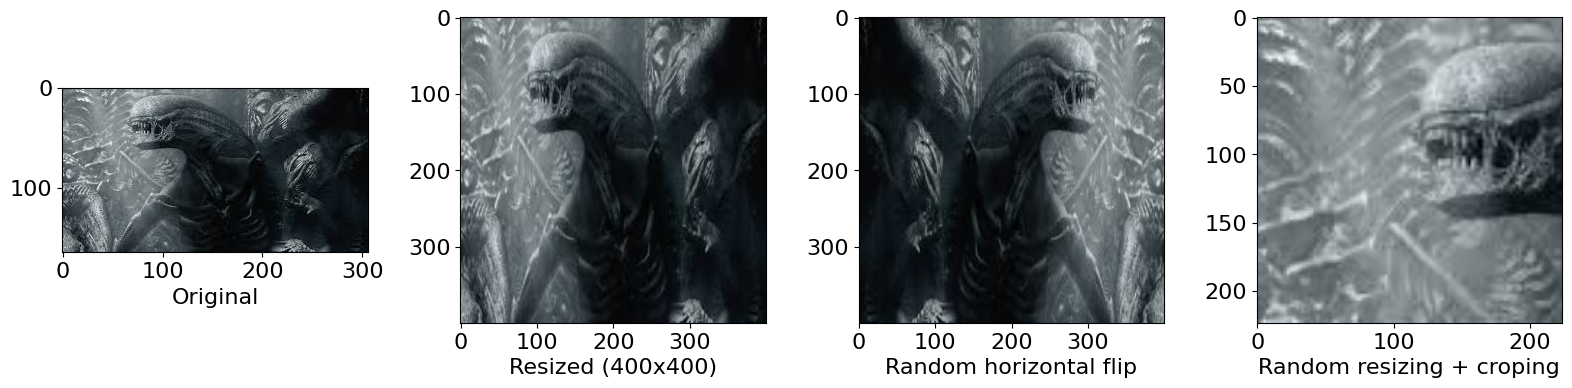

In [8]:
from torchvision.datasets import ImageFolder
from torchvision.transforms import (
    Compose,
    RandomResizedCrop,
    RandomHorizontalFlip,
    ToTensor,
    Resize,
    CenterCrop,
)

# Look at one image from the dataset
preview_data = ImageFolder(os.path.join(os.getcwd(), "data", "train"))
img, label = preview_data[2]
tensor_transformer = ToTensor()

# Let's inspect the effect of the various transformers
fig = plt.figure(figsize=(16, 9))

def show_image(img, label):
    # permute turns (rgb, height, width) into (height, width, rgb)
    plt.imshow(tensor_transformer(img).permute(1, 2, 0))
    plt.xlabel(label)

#################################################################################
#                          COMPLETE THE FOLLOWING SECTION                       #
#################################################################################

# transform image with some transformations and show them
plt.subplot(1, 4, 1)
show_image(img, label)
plt.xlabel("Original")

# Resized (400x400)
plt.subplot(1, 4, 2)
resize_transform = Resize((400, 400))
img_resized = resize_transform(img)
plt.imshow(tensor_transformer(img_resized).permute(1, 2, 0))
plt.xlabel("Resized (400x400)")

# Random horizontal flip
plt.subplot(1, 4, 3)
flip_transform = Compose([Resize((400, 400)), RandomHorizontalFlip(p=1.0)])
img_flipped = flip_transform(img)
plt.imshow(tensor_transformer(img_flipped).permute(1, 2, 0))
plt.xlabel("Random horizontal flip")

# Random resizing + cropping
plt.subplot(1, 4, 4)
crop_transform = RandomResizedCrop(224)
img_cropped = crop_transform(img)
plt.imshow(tensor_transformer(img_cropped).permute(1, 2, 0))
plt.xlabel("Random resizing + croping")

plt.tight_layout()
plt.show()
#################################################################################
#                                   THE END                                     #
#################################################################################


Note that the transformations above are random, so if you run the cell multiple times, you will see different results.

### Visualize some training samples

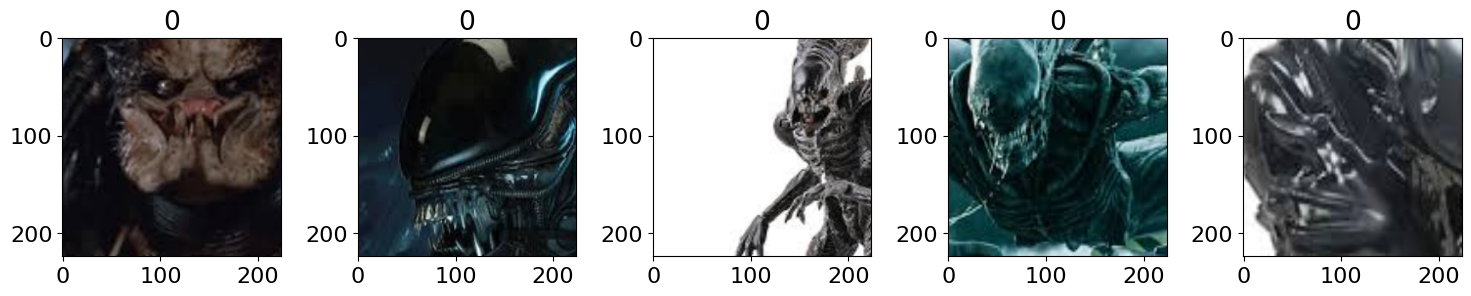

In [9]:
#################################################################################
#                          COMPLETE THE FOLLOWING SECTION                       #
#################################################################################

images, labels = next(iter(train_loader))
fig, ax = plt.subplots(1, 5, figsize=(15, 4))
for i in range(5):
    img, lbl = images[i], labels[i]
    ax[i].imshow(img.permute(1, 2, 0))
    ax[i].set_title(f'{label}')

plt.tight_layout()
plt.show()
#################################################################################
#                                   THE END                                     #
#################################################################################

---

# Loading a pre-trained model

### List of available pre-trained models

`torchvision` includes many pre-trained models. Let's get a list and have a look.

In [10]:
for model in dir(torchvision.models):
    if model.startswith("_"): continue  # Skip private properties
    print(f"- {model}")

- AlexNet
- AlexNet_Weights
- ConvNeXt
- ConvNeXt_Base_Weights
- ConvNeXt_Large_Weights
- ConvNeXt_Small_Weights
- ConvNeXt_Tiny_Weights
- DenseNet
- DenseNet121_Weights
- DenseNet161_Weights
- DenseNet169_Weights
- DenseNet201_Weights
- EfficientNet
- EfficientNet_B0_Weights
- EfficientNet_B1_Weights
- EfficientNet_B2_Weights
- EfficientNet_B3_Weights
- EfficientNet_B4_Weights
- EfficientNet_B5_Weights
- EfficientNet_B6_Weights
- EfficientNet_B7_Weights
- EfficientNet_V2_L_Weights
- EfficientNet_V2_M_Weights
- EfficientNet_V2_S_Weights
- GoogLeNet
- GoogLeNetOutputs
- GoogLeNet_Weights
- Inception3
- InceptionOutputs
- Inception_V3_Weights
- MNASNet
- MNASNet0_5_Weights
- MNASNet0_75_Weights
- MNASNet1_0_Weights
- MNASNet1_3_Weights
- MaxVit
- MaxVit_T_Weights
- MobileNetV2
- MobileNetV3
- MobileNet_V2_Weights
- MobileNet_V3_Large_Weights
- MobileNet_V3_Small_Weights
- RegNet
- RegNet_X_16GF_Weights
- RegNet_X_1_6GF_Weights
- RegNet_X_32GF_Weights
- RegNet_X_3_2GF_Weights
- RegNet_X_4

### We will use the ResNet-18 architecture:
![ResNet-picture](https://github.com/theevann/webconf-pytorch-workshop/blob/master/figures/resnet.png?raw=1)

It's very simple to create a module that has this model with its weights pre-trained for ImageNet.

In [11]:
#################################################################################
#                          COMPLETE THE FOLLOWING SECTION                       #
#################################################################################

# define pre_trained model
ResNet = torchvision.models.resnet18(pretrained=True)
ResNet

#################################################################################
#                                   THE END                                     #
#################################################################################

c:\Users\Radin\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Radin\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### A closer look at the ResNet-18

The last fully connected layer has a 1000 output neurons. It has been trained on ImageNet task which has 1000 image classes.

In [12]:
#################################################################################
#                          COMPLETE THE FOLLOWING SECTION                       #
#################################################################################

# print last layer of model
ResNet.fc

#################################################################################
#                                   THE END                                     #
#################################################################################

Linear(in_features=512, out_features=1000, bias=True)

We would like to perform binary classification (alien/predator). Therefore, we have to replace the last fully-connected layer to suit our needs (two output units).

In [13]:
#################################################################################
#                          COMPLETE THE FOLLOWING SECTION                       #
#################################################################################

# replace last layer with suitable layer
ResNet.fc = nn.Linear(in_features=512, out_features=2, bias=True)


#################################################################################
#                                   THE END                                     #
#################################################################################

---

# Training just the last layer

### Freeze all the layers except the last fully-connected one

**First way**

In [14]:
#################################################################################
#                          COMPLETE THE FOLLOWING SECTION                       #
#################################################################################

# Freeze all the layers except the last fully-connected one
for param in ResNet.parameters():
    param.requires_grad = False

for param in ResNet.fc.parameters():
    param.requires_grad = True

#################################################################################
#                                   THE END                                     #
#################################################################################

**Second way**

In [15]:
######### do not uncomment followings #########

ResNet.requires_grad_(False)
ResNet.fc.requires_grad_(True)

Linear(in_features=512, out_features=2, bias=True)

**Third way**

A third way could be to pass to the optimiser only the parameters of the last linear layer.  
However, this is not as good as the previous methods, do you see why ?  
Hint: All the gradients are still computed...

### Define the train and accuracy functions

So, now the architecture contains two output units, we can therefore use it to perform binary classification.

The *train* and _accuracy_ function are almost identical to the functions we used when traininig the CNN. This again nicely demonstrates the modularity of PyTorch and its simple interface.

In [16]:
#################################################################################
#                          COMPLETE THE FOLLOWING SECTION                       #
#################################################################################

# define accuracy function
def accuracy(pred, label):
    predict = pred.argmax(dim=1)
    correct = (predict == label).sum().item()
    total = label.size(0)
    return (correct / total) * 100

#################################################################################
#                                   THE END                                     #
#################################################################################

In [ ]:
from tqdm import tqdm

#################################################################################
#                          COMPLETE THE FOLLOWING SECTION                       #
#################################################################################
def train(
    model,
    train_loader,
    test_loader,
    device,
    num_epochs=3,
    learning_rate=0.1,
    decay_learning_rate=False,
):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    best_val_loss = np.inf
    pred_list = []
    true_list = []

    for epoch in range(num_epochs):
        train_loss = 0.0
        train_acc = 0.0
        model.train()

        for image, label in train_loader:
            output = ResNet(image)
            loss = criterion(output, label)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_acc += accuracy(output, label)

        val_loss = 0.0
        val_acc = 0.0
        model.eval()
        with torch.no_grad():
            for image, label in test_loader:
                output = model(image)
                loss = criterion(output, label)
                val_loss += loss.item()
                val_acc += accuracy(output, label)
                for x in output.argmax(dim=1).numpy(): pred_list.append(x)
                for i in label.numpy(): true_list.append(i)

        avg_train = train_loss / len(train_loader)
        avg_train_acc = train_acc / len(train_loader)
        avg_val_acc = val_acc / len(test_loader)
        avg_valid = val_loss / len(test_loader)

        if avg_valid < best_val_loss:
            print(f'{avg_valid:.4f} is better then {best_val_loss:.4f} ---> Saving...')
            best_val_loss = avg_valid
            torch.save(model.state_dict(), './content/Resnet.pt')

        print(f"Epoch {epoch+1}: Train Loss:{avg_train:.4f}, Test Loss:{avg_valid:.4f}, Accuracy Train:{avg_train_acc:.2f}% Accuracy Test:{avg_val_acc:.2f}%")

    return pred_list, true_list

#################################################################################
#                                   THE END                                     #
#################################################################################

### Launch training

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ResNet.to(device)

pred_list, true_list = train(ResNet, train_loader, test_loader, device, num_epochs=15, learning_rate=0.01)

0.8603 is better then inf ---> Saving...
Epoch 1: Train Loss:0.8211, Test Loss:0.8603, Accuracy Train:0.92% Accuracy Test:0.95%
0.8495 is better then 0.8603 ---> Saving...
Epoch 2: Train Loss:0.8860, Test Loss:0.8495, Accuracy Train:0.91% Accuracy Test:0.94%
0.8487 is better then 0.8495 ---> Saving...
Epoch 3: Train Loss:0.8751, Test Loss:0.8487, Accuracy Train:0.92% Accuracy Test:0.94%
Epoch 4: Train Loss:0.8858, Test Loss:1.1243, Accuracy Train:0.93% Accuracy Test:0.92%
0.8150 is better then 0.8487 ---> Saving...
Epoch 5: Train Loss:1.2781, Test Loss:0.8150, Accuracy Train:0.90% Accuracy Test:0.95%
Epoch 6: Train Loss:1.1636, Test Loss:0.8777, Accuracy Train:0.90% Accuracy Test:0.95%
0.8047 is better then 0.8150 ---> Saving...
Epoch 7: Train Loss:0.8913, Test Loss:0.8047, Accuracy Train:0.92% Accuracy Test:0.95%
0.7758 is better then 0.8047 ---> Saving...
Epoch 8: Train Loss:0.6374, Test Loss:0.7758, Accuracy Train:0.93% Accuracy Test:0.94%
0.7647 is better then 0.7758 ---> Saving...

In [ ]:
ResNet.load_state_dict(torch.load('./content/Resnet.pt'))
ResNet.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
correct = 0
total = 0
y_pred_list = []
y_true_list = []
with torch.no_grad():
    for data, labels in test_loader:

        predicted = ResNet(data).argmax(dim=1)
        
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        for  x in predicted.cpu().numpy(): y_pred_list.append(x)
        for  x in labels.cpu().numpy(): y_true_list.append(x)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true_list, y_pred_list, target_names=train_data.classes))

              precision    recall  f1-score   support

       alien       0.94      0.93      0.93       100
    predator       0.93      0.94      0.94       100

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.93       200
weighted avg       0.94      0.94      0.93       200



### Inspecting the model's predictions

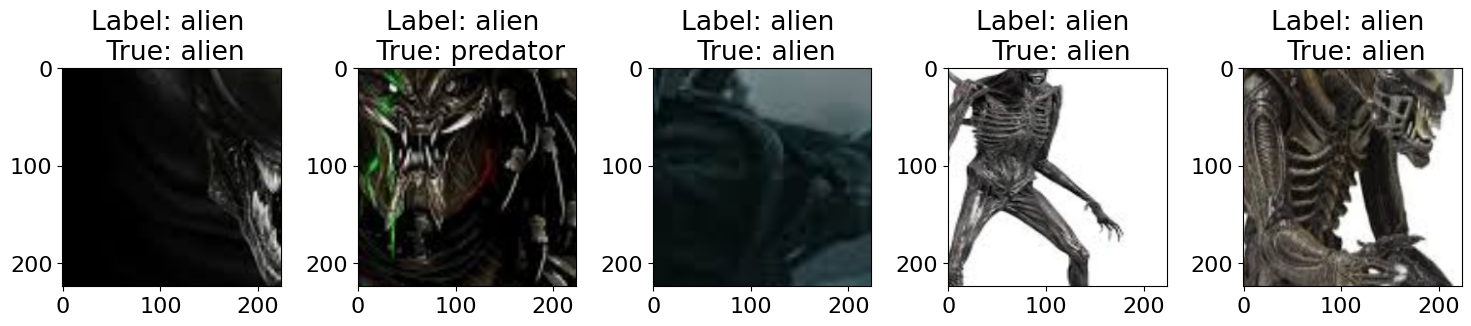

In [ ]:
#################################################################################
#                          COMPLETE THE FOLLOWING SECTION                       #
#################################################################################
# show some predictions
images, labels = next(iter(train_loader))
fig, ax = plt.subplots(1, 5, figsize=(15, 5))
predicted = ResNet(images).argmax(dim=1)
classes = train_data.classes

for i in range(5):
    img, lbl = images[i], labels[i]
    ax[i].imshow(img.permute(1, 2, 0))
    ax[i].set_title(f'Label: {classes[label]} \n True: {classes[predicted[i]]}')

plt.tight_layout()
plt.show()

#################################################################################
#                                   THE END                                     #
#################################################################################